# Response Quality Check — Detecting Trivial / Careless Responses

Before building the opinion network, we check for respondents whose answer patterns
look "trivial" (e.g. selecting the same option for almost every statement, or
straight-lining) rather than genuinely engaging with each item. Such responses can
artificially inflate similarity between respondents and distort correlation/network
structure, so we want to identify — and gauge the impact of — them here.

This is a companion notebook to `EDA.ipynb`; it does not modify the main EDA, it only
flags rows worth scrutinizing (and optionally excluding) before network construction.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)

## 1. Load and encode

Same encoding as `EDA.ipynb`: Likert responses mapped to -2..+2, blanks/"No Comments" → `NaN`.

In [2]:
df = pd.read_csv("Survey_Results_UC.csv", encoding="utf-8-sig")
df = df.rename(columns={"id. Response ID": "respondent_id"}).set_index("respondent_id")

likert_map = {
    "Strongly Disagree": -2,
    "Disagree": -1,
    "Neutral": 0,
    "Agree": 1,
    "Strongly Agree": 2,
}

df_num = df.replace({"": np.nan, "No Comments": np.nan}).replace(likert_map).apply(pd.to_numeric)

category_map = {col: col[0] for col in df.columns}
category_names = {"T": "Technology", "E": "Education", "S": "Ethics/Society", "V": "Environment"}

print(f"Respondents: {df.shape[0]}, Statements: {df.shape[1]}")
df_num.head()

Respondents: 96, Statements: 60


,T01. Artificial Intelligence will improve society more than it will create problems.,T02. Generative AI tools should be allowed as learning aids in higher education.,T03. Students should disclose the use of AI in assignments and reports.,T04. Every engineering student should receive formal education in AI.,T05. Artificial Intelligence will significantly accelerate scientific discovery.,T06. Most repetitive jobs will eventually be replaced by intelligent automation.,T07. Robots should replace humans in hazardous occupations whenever possible.,T08. AI-assisted diagnosis should become routine in healthcare.,T09. Autonomous vehicles will ultimately make transportation safer.,T10. Protection of personal data is more important than technological convenience.,T11. Technology companies should explain how recommendation algorithms work.,T12. Governments should introduce stricter regulations for Artificial Intelligence.,T13. Cybersecurity deserves greater investment than the development of new digital technologies.,T14. Social media algorithms contribute to opinion polarization.,T15. Society will increasingly depend on AI-assisted decision making.,E01. Project-based learning develops deeper understanding than examination-oriented learning.,E02. Traditional written examinations accurately measure a student's knowledge.,E03. Class attendance should be compulsory for all courses.,E04. High-quality online learning can effectively complement classroom teaching.,E05. Students should be encouraged to take courses outside their primary discipline.,E06. Every undergraduate student should participate in at least one research project.,"E07. Publishing research before graduation should be encouraged, but not mandatory.",E08. Maintaining academic honesty is more important than obtaining high grades.,E09. Collaborative learning is generally more effective than individual learning.,E10. Universities should prioritize innovation and problem-solving over rote learning.,E11. University curricula should be updated more frequently to match emerging technologies.,E12. Artificial intelligence should be integrated into teaching and personalized learning.,E13. Universities should invest more resources in research than in expanding infrastructure.,E14. Strong collaborations between universities and industry improve student education.,E15. Continuous learning and skill development are essential throughout one's career.,S01. Every individual has a responsibility to contribute positively to society.,S02. Universities should encourage students to participate in community service activities.,S03. New technologies should be evaluated for their societal impact before widespread deployment.,S04. Technology companies should be accountable for unethical use of their platforms.,S05. Individuals should have greater control over how their personal data are collected and used.,"S06. Combating online misinformation requires shared responsibility among users, platforms, and governments.",S07. Equal opportunities should be prioritized regardless of a person's background.,S08. Diverse teams generally make better decisions than homogeneous teams.,S09. Universities should promote an inclusive environment where different viewpoints can be discussed respectfully.,S10. Scientific evidence should play an important role in public policy decisions.,S11. People should be free to express differing opinions as long as they do not promote harm or discrimination.,S12. Young people should actively participate in addressing societal challenges.,S13. Critical evaluation of online information should be taught as a core educational skill.,S14. Leaders should prioritize ethical decision-making even when it reduces short-term gains.,S15. Building public trust is essential for responsible adoption of emerging technologies.,V01. Climate change requires immediate global action.,V02. Governments should prioritize investment in renewable energy over fossil fuels.,V03. Individuals should actively reduce

## 2. Per-respondent "trace" metrics

For each respondent's row (their trace across all 60 statements) compute a few
straight-lining / carelessness indicators:

- **`n_unique`** — how many distinct answer values they used (2 = almost binary responding).
- **`mode_share`** — fraction of their answers equal to their single most common answer
  (close to 1.0 = they picked essentially the same option throughout).
- **`std`** — standard deviation of their numeric answers (near 0 = flat trace).
- **`longest_run`** — longest streak of *consecutive* identical answers (by statement
  order), a classic straight-lining signal since it also captures local flat-lining,
  not just overall.
- **`n_missing`** — blank / "No Comments" answers.

In [3]:
def longest_run(row):
    vals = row.dropna().values
    if len(vals) == 0:
        return 0
    best = cur = 1
    for a, b in zip(vals, vals[1:]):
        cur = cur + 1 if a == b else 1
        best = max(best, cur)
    return best


missing_mask = df.isin(["", "No Comments"]) | df.isna()

traces = pd.DataFrame({
    "n_unique": df_num.apply(lambda r: r.dropna().nunique(), axis=1),
    "mode_share": df_num.apply(lambda r: r.dropna().value_counts(normalize=True).max() if r.notna().any() else np.nan, axis=1),
    "std": df_num.std(axis=1, skipna=True),
    "longest_run": df_num.apply(longest_run, axis=1),
    "n_missing": missing_mask.sum(axis=1),
})
traces["run_frac"] = traces["longest_run"] / df_num.shape[1]

traces.sort_values("mode_share", ascending=False).head(10)

,n_unique,mode_share,std,longest_run,n_missing,run_frac
respondent_id,,,,,,
41,5,0.866667,0.721737,25,0,0.416667
94,4,0.850000,0.679606,37,0,0.616667
91,3,0.800000,0.418499,22,0,0.366667
110,5,0.800000,0.770025,42,0,0.700000
54,5,0.783333,0.946447,22,0,0.366667
21,4,0.766667,0.869281,23,0,0.383333
37,4,0.750000,0.891105,13,0,0.216667
105,4,0.733333,0.761169,16,0,0.266667
50,5,0.716667,0.851055,14,0,0.233333


## 3. Visualize the indicators

Look at the distributions of `mode_share`, `std`, and `longest_run` across all 96
respondents to see whether trivial responders stand out as outliers or form a
continuum with everyone else.

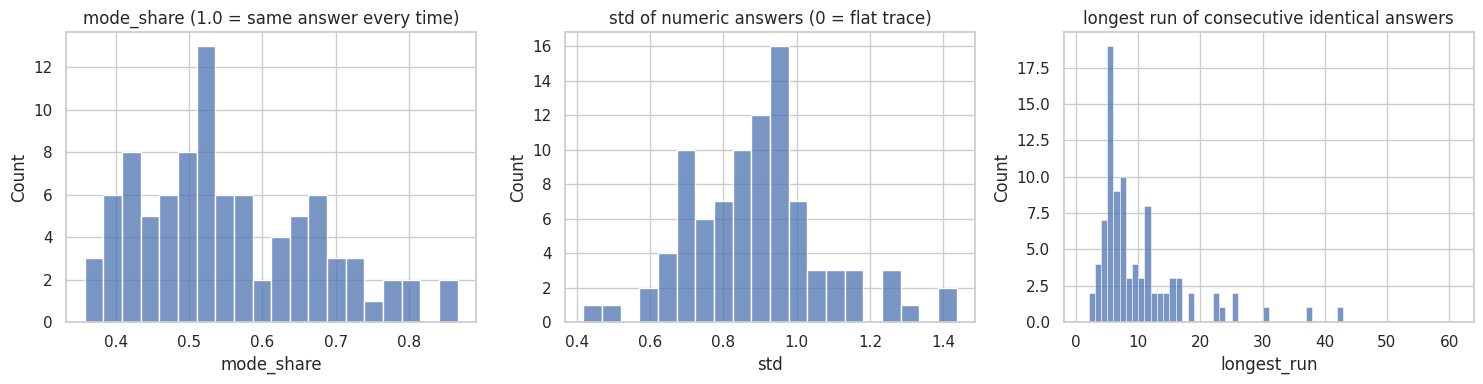

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(traces["mode_share"], bins=20, ax=axes[0])
axes[0].set_title("mode_share (1.0 = same answer every time)")

sns.histplot(traces["std"], bins=20, ax=axes[1])
axes[1].set_title("std of numeric answers (0 = flat trace)")

sns.histplot(traces["longest_run"], bins=range(1, df_num.shape[1] + 2), ax=axes[2])
axes[2].set_title("longest run of consecutive identical answers")

plt.tight_layout()
plt.show()

## 4. Eyeballing the actual traces

Plot every respondent's raw answer sequence (statement order = T01..T15, E01..E15,
S01..S15, V01..V15) as one line each. A respondent who is answering thoughtfully should
show visible up/down movement as topics change; a flat or near-flat line across all 60
statements is the visual signature of a trivial/straight-lined response.

Flagged as potentially trivial: 5 / 96 respondents


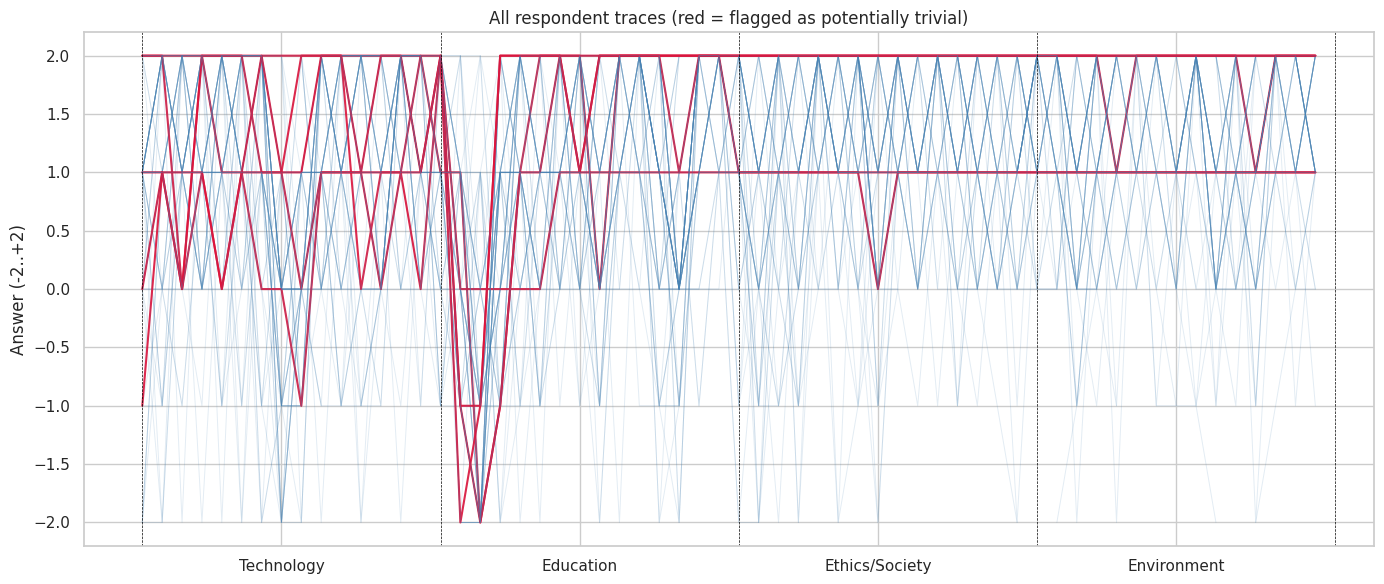

In [5]:
# Flag candidates up front so we can highlight them in the trace plot below.
# Thresholds are deliberately loose "smells", not hard exclusion rules.
flag = (
    (traces["mode_share"] >= 0.8)
    | (traces["std"] <= 0.3)
    | (traces["run_frac"] >= 0.5)
)
print(f"Flagged as potentially trivial: {flag.sum()} / {len(flag)} respondents")

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(df_num.shape[1])
for rid, row in df_num.iterrows():
    ax.plot(x, row.values, color="crimson" if flag[rid] else "steelblue",
            alpha=0.9 if flag[rid] else 0.15, linewidth=1.5 if flag[rid] else 0.7)

for boundary, label in zip([0, 15, 30, 45, 60], ["T", "E", "S", "V", ""]):
    ax.axvline(boundary, color="black", linewidth=0.5, linestyle="--")
ax.set_xticks([7, 22, 37, 52])
ax.set_xticklabels(["Technology", "Education", "Ethics/Society", "Environment"])
ax.set_ylabel("Answer (-2..+2)")
ax.set_title("All respondent traces (red = flagged as potentially trivial)")
plt.tight_layout()
plt.show()

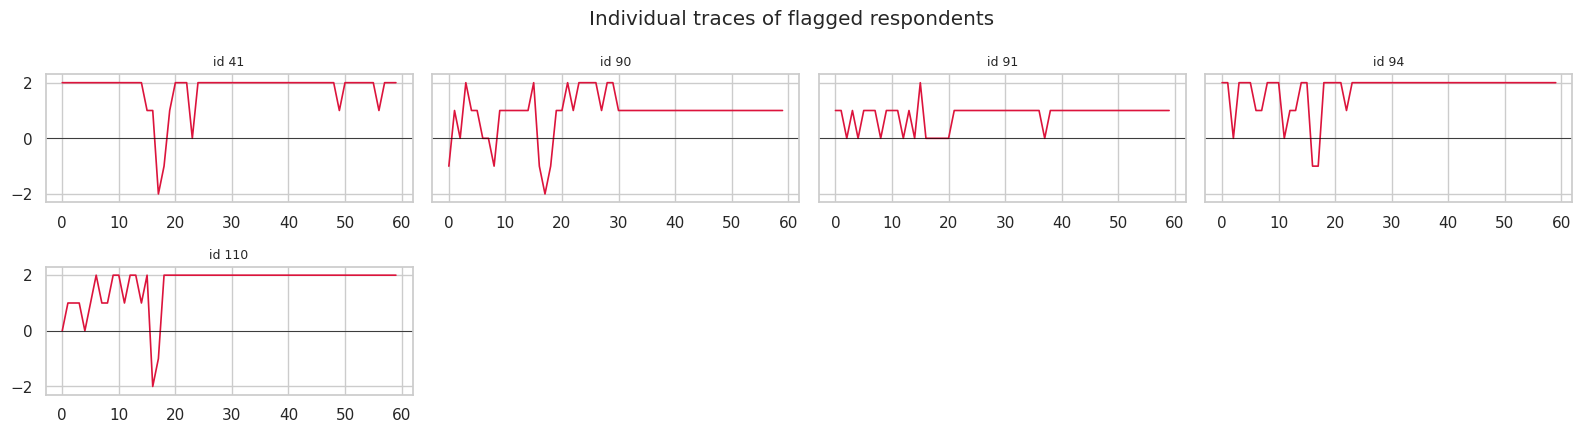

In [6]:
flagged_ids = traces.index[flag]
n_flagged = len(flagged_ids)

if n_flagged > 0:
    ncols = 4
    nrows = int(np.ceil(n_flagged / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 2.2 * nrows), sharey=True)
    axes = np.atleast_1d(axes).ravel()
    for ax, rid in zip(axes, flagged_ids):
        ax.plot(x, df_num.loc[rid].values, color="crimson", linewidth=1.2)
        ax.axhline(0, color="black", linewidth=0.5)
        ax.set_title(f"id {rid}", fontsize=9)
        ax.set_ylim(-2.3, 2.3)
    for ax in axes[n_flagged:]:
        ax.axis("off")
    fig.suptitle("Individual traces of flagged respondents")
    plt.tight_layout()
    plt.show()
else:
    print("No respondents flagged.")

In [7]:
traces.loc[flagged_ids].sort_values("mode_share", ascending=False)

,n_unique,mode_share,std,longest_run,n_missing,run_frac
respondent_id,,,,,,
41,5,0.866667,0.721737,25,0,0.416667
94,4,0.850000,0.679606,37,0,0.616667
91,3,0.800000,0.418499,22,0,0.366667
110,5,0.800000,0.770025,42,0,0.700000
90,5,0.716667,0.787437,30,0,0.500000


## 5. Do these respondents actually distort the analysis?

A flat trace is suspicious on its own, but what matters for the network is whether it
inflates similarity edges. A respondent with `std ≈ 0` has an undefined or near-zero
correlation with everyone (Pearson r needs variance), so straight-liners tend to drop
*out* of a correlation-based similarity network rather than corrupt it — but they can
still distort **mean/aggregate** statistics (category means, "consensus" statements).
Check both effects directly: compare respondent-pair similarity and per-statement means
with vs. without the flagged rows.

In [8]:
df_clean = df_num.drop(index=flagged_ids)

# --- Effect on statement means ---
mean_shift = (df_num.mean() - df_clean.mean()).rename("mean_shift").to_frame()
mean_shift["abs_shift"] = mean_shift["mean_shift"].abs()
print("Statements whose mean score shifts most once flagged respondents are removed:")
display(mean_shift.sort_values("abs_shift", ascending=False).head(10))

# --- Effect on respondent-pair similarity involving flagged respondents ---
respondent_sim_full = df_num.T.corr()
sim_with_flagged = respondent_sim_full.loc[flagged_ids].drop(columns=flagged_ids, errors="ignore")
print("\nSimilarity of flagged respondents to everyone else (Pearson r, NaN = undefined due to zero variance):")
display(sim_with_flagged.stack().describe())

Statements whose mean score shifts most once flagged respondents are removed:


,mean_shift,abs_shift
E13. Universities should invest more resources in research than in expanding infrastructure.,0.078676,0.078676
T08. AI-assisted diagnosis should become routine in healthcare.,0.054248,0.054248
E12. Artificial intelligence should be integrated into teaching and personalized learning.,0.052986,0.052986
S02. Universities should encourage students to participate in community service activities.,0.046398,0.046398
V03. Individuals should actively reduce their personal energy consumption.,0.039190,0.039190
E09. Collaborative learning is generally more effective than individual learning.,0.037611,0.037611
V10. Consumers should consider environmental impact when purchasing products.,0.035294,0.035294
E06. Every undergraduate student should participate in at least one research project.,0.032587,0.032587
T09. Autonomous vehicles will ultimately make transportation safer.,0.030719,0.030719
"E07. Publishing research before graduation should be encouraged, but not mandatory.",0.030558,0.030558



Similarity of flagged respondents to everyone else (Pearson r, NaN = undefined due to zero variance):


count    426.000000
mean       0.307180
std        0.197291
min       -0.496724
25%        0.172273
50%        0.320399
75%        0.455903
max        0.754530
dtype: float64

## 6. Conclusion / recommendation

The cell above quantifies, rather than assumes, how much the flagged respondents move
the numbers. Rules of thumb for the network-construction step:

- If a flagged respondent's `std` is at/near 0, their correlation with every other
  respondent is undefined (`NaN`) or meaningless — they should either be **excluded**
  from a correlation/Pearson-similarity network, or handled with a similarity metric
  that tolerates zero variance (e.g. Euclidean/Manhattan distance on raw scores instead
  of correlation).
- If the mean shift from removing flagged rows is small (a fraction of a Likert point)
  for most statements, keeping them only biases aggregate/"consensus" statistics
  slightly — a judgment call rather than a must-exclude.
- `flagged_ids` (below) is the working exclusion list; adjust the thresholds in
  Section 4 if this looks too strict/loose for the actual data.

In [9]:
print("Flagged respondent IDs:", list(flagged_ids))

Flagged respondent IDs: [41, 90, 91, 94, 110]
